In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [3]:
X = 6*np.random.rand(200,1) - 3
y = 8.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)

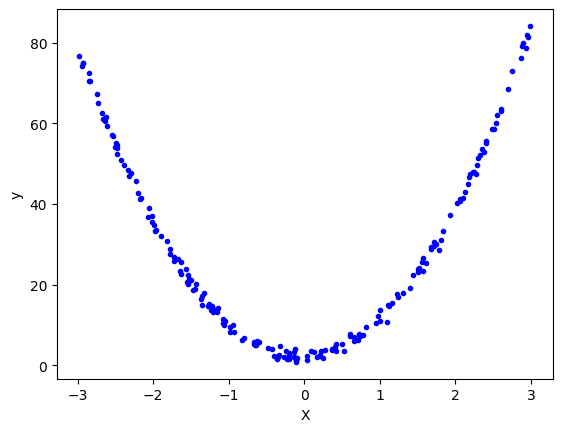

In [4]:
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 2)

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred  = lr.predict(X_test)
r2_score(y_test,y_pred)

-0.010645271800858502

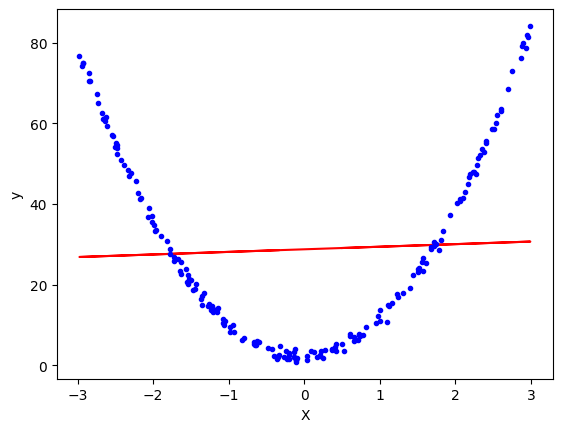

In [14]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [15]:
poly = PolynomialFeatures(degree = 2)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [16]:
print(X_train[0])
print(X_train_trans[0])

[-0.33909247]
[ 1.         -0.33909247  0.1149837 ]


In [18]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_pred = lr.predict(X_test_trans)

In [20]:
r2_score(y_test,y_pred)

0.9984407871376892

In [21]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.8595533  8.77586643]]
[2.11602737]


In [23]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

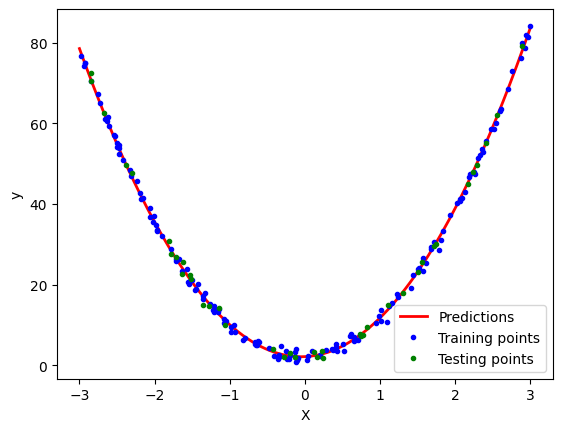

In [28]:
plt.plot(X_new,y_new,"r-",linewidth=2,label="Predictions")
plt.plot(X_train,y_train,"b.",label='Training points')
plt.plot(X_test,y_test,"g.",label='Testing points')

plt.xlabel("X")
plt.ylabel("y")

plt.legend()
plt.show()

In [29]:
# 3D polynomial regression
x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8
z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + np.random.randn(100,1)


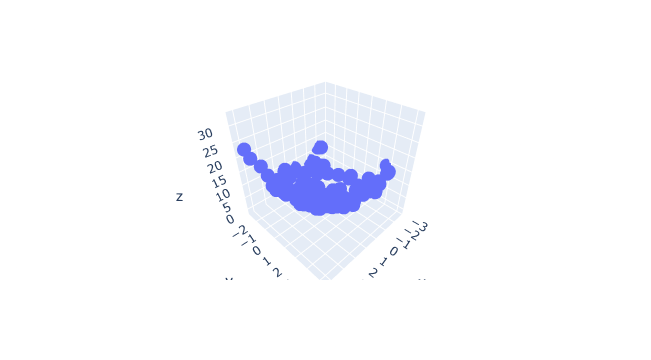

In [30]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df,x = x.ravel(),y=y.ravel(),z=z.ravel())
fig.show()